# Laboratorio 7 — Regresión Logística
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Variables dicotómicas por categoría de precio

Se pide construir **tres variables dicotómicas (0/1)** a partir de la variable respuesta categórica `price_category` creada en los laboratorios anteriores:

- `es_cara` → 1 si la vivienda es *cara*, 0 en cualquier otro caso.
- `es_media` → 1 si la vivienda es de precio *medio*, 0 en cualquier otro caso.
- `es_economica` → 1 si la vivienda es *económica*, 0 en cualquier otro caso.

Para mantener la reproducibilidad respecto a laboratorios previos se reutilizan los **mismos cortes por tercios (q1 = 33%, q2 = 66%)** sobre `price_num` y las mismas etiquetas usadas en el lab anterior.

In [1]:
# Librerías base para carga de datos y manipulación tabular
import pyreadr
import pandas as pd
import numpy as np

# Semilla fija para reproducibilidad en pasos posteriores del laboratorio
SEED = 42
np.random.seed(SEED)

In [2]:
# Lectura del RData original de listings (mismo archivo usado en labs anteriores)
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

# Tamaño original del dataset antes de cualquier limpieza
print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [3]:
# Normalización de la columna `price` a numérico, replicando la limpieza
# ya validada en los laboratorios previos: se remueven símbolos de moneda y
# separadores de miles, se tratan strings vacíos como nulos y se descartan
# filas sin precio (no se pueden clasificar sin la variable objetivo).
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio: {filas_antes:,}")
print(f"Filas con precio válido:       {len(df):,}")

Filas antes de limpiar precio: 171,748
Filas con precio válido:       76,246


In [4]:
# Cortes por tercios sobre price_num: mismos umbrales usados en el lab anterior
# para construir la variable categórica de precio. Se usan tercios (33%-66%)
# para obtener tres grupos balanceados en cantidad de observaciones.
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

# Construcción de la variable categórica de precio (3 niveles)
df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

# Conteo por categoría para verificar balance
print("\nDistribución de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribución de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [5]:
# Creación de las tres variables dicotómicas pedidas en el inciso 1.
# Cada una es 1 cuando la observación pertenece a esa categoría, 0 en caso contrario.
df["es_cara"]      = (df["price_category"] == "cara").astype(int)
df["es_media"]     = (df["price_category"] == "media").astype(int)
df["es_economica"] = (df["price_category"] == "economica").astype(int)

# Resumen: totales y proporción de 1s por cada variable dicotómica
resumen = pd.DataFrame({
    "total_1s":  df[["es_cara", "es_media", "es_economica"]].sum(),
    "proporcion": df[["es_cara", "es_media", "es_economica"]].mean().round(4),
})
print(resumen)

# Chequeo de integridad: las tres variables deben ser mutuamente excluyentes
# y colectivamente exhaustivas, es decir, la suma por fila siempre debe ser 1.
suma_filas_ok = (df[["es_cara", "es_media", "es_economica"]].sum(axis=1) == 1).all()
print(f"\n¿Cada fila pertenece a exactamente 1 categoría? {suma_filas_ok}")

# Vista previa de las columnas generadas junto al precio y la categoría
df[["price_num", "price_category", "es_cara", "es_media", "es_economica"]].head(10)

              total_1s  proporcion
es_cara          25404      0.3332
es_media         25153      0.3299
es_economica     25689      0.3369

¿Cada fila pertenece a exactamente 1 categoría? True


,price_num,price_category,es_cara,es_media,es_economica
0,97.0,economica,0,0,1
1,160.0,media,0,1,0
2,38.0,economica,0,0,1
3,145.0,media,0,1,0
4,58.0,economica,0,0,1
5,49.0,economica,0,0,1
6,300.0,cara,1,0,0
7,150.0,media,0,1,0
8,165.0,media,0,1,0
9,117.0,economica,0,0,1


### Observaciones y conclusiones del inciso 1

- Del dataset original (171,748 filas) quedaron 76,246 filas después de quitar las que no tenían precio. Esas son las filas con las que se va a trabajar el resto del laboratorio.
- Los cortes por tercios dieron q1 = 143 y q2 = 268. Con esos valores las casas quedan así: económica si el precio es menor o igual a 143, media si está entre 143 y 268, y cara si pasa de 268.
- Las tres categorías quedaron casi del mismo tamaño (cada una cerca del 33%): 25,689 económicas, 25,153 medias y 25,404 caras. Que estén balanceadas ayuda porque el modelo no va a estar sesgado hacia una clase y la exactitud se puede leer directamente.
- Se generaron las tres variables dicotómicas `es_cara`, `es_media` y `es_economica`. Cada fila cae en una sola categoría (se verificó que la suma por fila siempre da 1), así que no hay solapes ni filas sin clasificar.
- `es_cara` es la que se va a usar como variable respuesta en el inciso 3. Las otras dos quedan guardadas por si se quiere repetir el análisis con otra categoría más adelante.
- El proceso es reproducible: misma fuente de datos, misma limpieza y mismos cuantiles, por lo que la categorización coincide con la que se hizo en los laboratorios 5 y 6.

## Inciso 2 — Conjuntos de entrenamiento y prueba (reproducibles)

Se replica exactamente la partición usada en los laboratorios 5 y 6:

- División **70% entrenamiento / 30% prueba** con `train_test_split`.
- `random_state = 42` para que la partición sea idéntica entre ejecuciones.
- `stratify` sobre `es_cara` para preservar la proporción de clases en ambos subconjuntos (el laboratorio 7 se enfoca en clasificación binaria *cara / no cara*).

Antes de dividir se replica la **limpieza y selección de variables predictoras** validada en el laboratorio 6: eliminación de identificadores y texto libre, descarte de columnas con >50% de nulos, conversión de booleanos `t/f`, parsing de porcentajes, imputación por mediana en numéricas y relleno con `"desconocido"` en categóricas. Se excluyen además variables con fuga de información (`host_id`, `estimated_occupancy_l365d`, `estimated_revenue_l365d`) y las columnas derivadas del precio (`price`, `price_num`, `price_category`, `es_media`, `es_economica`) para que no filtren la respuesta.

In [6]:
# Importaciones necesarias para la partición reproducible
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

# --- Preparación de df_model replicando el pipeline del laboratorio 6 ---
df_model = df.copy()

# Columnas descartadas: identificadores, URLs, texto libre y fechas no utilizables
cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

# Descartar columnas con más del 50% de valores nulos (poca información útil)
high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

# Booleanos de Airbnb codificados como t/f → 1/0
bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

# Porcentajes como texto ("95%") convertidos a fracción numérica
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

# Forzar tipo numérico en columnas que pueden llegar como object
force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Imputación: mediana para numéricas, "desconocido" para categóricas
numeric_cols_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()
df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())
for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model:   {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model:   60


/var/folders/cm/f6sv26g17tn_3m0hz351pldw0000gn/T/ipykernel_13128/2373693284.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()


In [7]:
# Variables con fuga de información (no pueden usarse como predictoras porque
# contienen información derivada directamente del precio o del resultado final)
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
                     if c in df_model.columns]

# Matriz de predictores X y variable respuesta binaria y (es_cara)
# Se remueven todas las columnas derivadas del precio para evitar que filtren la respuesta.
leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")
y_cara  = df_model["es_cara"].copy()

# Clasificación de columnas predictoras por tipo (útil para pipelines posteriores)
numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas:   {len(numerical_columns)}")
print(f"  Categóricas: {len(categorical_columns)}")

Variables predictoras: 51
  Numéricas:   44
  Categóricas: 7


In [8]:
# Partición 70/30 fija y estratificada por la clase es_cara
# random_state=42 garantiza que el split sea idéntico en cada ejecución
# y consistente con laboratorios anteriores.
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_cara,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_cara,
)

print("=== Partición 70/30 estratificada ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Verificar que la proporción de la clase 1 (cara) se mantiene en ambos subconjuntos
proporciones = pd.DataFrame({
    "es_cara=1 (prop.)": [y_train.mean(), y_test.mean(), y_cara.mean()],
    "n":                 [len(y_train), len(y_test), len(y_cara)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Partición 70/30 estratificada ===
X_train: (53372, 51)
X_test:  (22874, 51)
y_train: (53372,)
y_test:  (22874,)

       es_cara=1 (prop.)      n
train             0.3332  53372
test              0.3332  22874
total             0.3332  76246


### Observaciones y conclusiones del inciso 2

- La partición se hace con `random_state=42` y 70/30, que es la misma configuración que se usó en los laboratorios anteriores. Eso asegura que cada vez que se corra el código salgan exactamente las mismas filas en entrenamiento y prueba.
- Entrenamiento quedó con 53,372 filas y prueba con 22,874. Después de la limpieza se trabaja con 51 variables predictoras: 44 numéricas y 7 categóricas.
- Como la partición es estratificada, la proporción de casas caras se mantiene en 0.3332 tanto en train como en test. Eso evita que por azar alguna de las dos muestras quede con muy pocas casas caras y se distorsionen las métricas.
- Se quitaron a propósito todas las columnas que vienen del precio (`price`, `price_num`, `price_category`, `es_media`, `es_economica`) para que el modelo no haga trampa prediciendo con información que ya contiene la respuesta.
- También se descartaron `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d` porque son variables con fuga: se calculan después del precio o están ligadas al resultado que se quiere predecir.
- Como se parte del mismo archivo `listings.RData`, se aplica la misma limpieza y se usa la misma semilla, los conjuntos son comparables con los que se usaron en los labs 5 y 6. La única diferencia es que aquí la variable respuesta es binaria (`es_cara`) en lugar del precio continuo o la categoría de tres niveles.

## Inciso 3 — Modelo de regresión logística (¿es cara o no?)

Se construye un modelo de regresión logística para predecir si una vivienda es **cara** (`es_cara = 1`) o no (`es_cara = 0`), usando el conjunto de entrenamiento del inciso 2.

El pipeline que se usa hace lo siguiente:

- Escala las variables numéricas con `StandardScaler` (la regresión logística es sensible a la escala cuando se regulariza).
- Codifica las variables categóricas con One-Hot. Antes de eso se reduce la cardinalidad dejando solo las 20 categorías más frecuentes por columna y agrupando el resto como `"otro"`, para que la matriz expandida no crezca demasiado.
- Ajusta `LogisticRegression` con `solver="lbfgs"`, `max_iter=1000` y `random_state=42`.

La validación cruzada se hace con `StratifiedKFold` de 5 particiones (también con `random_state=42`) para que sea reproducible y mantenga la proporción de clases en cada fold.

In [9]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Reducir cardinalidad de las columnas categóricas: dejar solo las 20 categorías
# más frecuentes y marcar el resto como "otro". Esto evita que el One-Hot genere
# miles de columnas por categorías raras (ej: barrios con muy pocos listings).
TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

# Preprocesamiento: escalar numéricas + One-Hot para categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

# Modelo de regresión logística con tope alto de iteraciones para que converja
logreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)),
])

print("Pipeline listo para entrenar.")

Pipeline listo para entrenar.


In [10]:
# Validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento.
# Se reporta accuracy por fold + promedio y desviación estándar.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
cv_scores = cross_val_score(logreg_pipe, X_train_r, y_train, cv=cv,
                            scoring="accuracy", n_jobs=-1)
tiempo_cv = time.time() - t0

print("=== Validación cruzada (5-fold, estratificada) ===")
print(f"Accuracy por fold: {np.round(cv_scores, 4)}")
print(f"Accuracy media:    {cv_scores.mean():.4f}")
print(f"Desv. estándar:    {cv_scores.std():.4f}")
print(f"Tiempo total CV:   {tiempo_cv:.2f} s")

=== Validación cruzada (5-fold, estratificada) ===
Accuracy por fold: [0.841  0.8389 0.8365 0.835  0.8376]
Accuracy media:    0.8378
Desv. estándar:    0.0020
Tiempo total CV:   1.98 s


In [11]:
# Entrenamiento final del modelo usando todo el conjunto de entrenamiento
t0 = time.time()
logreg_pipe.fit(X_train_r, y_train)
tiempo_fit = time.time() - t0

train_acc = logreg_pipe.score(X_train_r, y_train)
test_acc  = logreg_pipe.score(X_test_r,  y_test)

print(f"Tiempo de entrenamiento:  {tiempo_fit:.2f} s")
print(f"Accuracy en entrenamiento: {train_acc:.4f}")
print(f"Accuracy en prueba:        {test_acc:.4f}")

Tiempo de entrenamiento:  0.33 s
Accuracy en entrenamiento: 0.8392
Accuracy en prueba:        0.8413


In [12]:
# Inspección de los coeficientes del modelo ya entrenado.
# Un coeficiente positivo empuja la predicción hacia "cara"; uno negativo la aleja.
ohe = logreg_pipe.named_steps["pre"].named_transformers_["cat"]
feature_names = list(numerical_columns) + list(ohe.get_feature_names_out(categorical_columns))
coefs = pd.Series(logreg_pipe.named_steps["clf"].coef_[0], index=feature_names)

print(f"Total de variables tras One-Hot: {len(feature_names)}")
print(f"Intercepto: {logreg_pipe.named_steps['clf'].intercept_[0]:.4f}\n")

print("Top 10 variables que más empujan hacia 'cara':")
print(coefs.sort_values(ascending=False).head(10).round(4).to_string())
print("\nTop 10 variables que más empujan hacia 'no cara':")
print(coefs.sort_values().head(10).round(4).to_string())

Total de variables tras One-Hot: 134
Intercepto: -0.3109

Top 10 variables que más empujan hacia 'cara':
property_type_Room in boutique hotel               1.7841
property_type_Private room in resort               1.7475
city_Boston, Massachusetts                         1.7226
neighbourhood_cleansed_78701                       1.4399
property_type_Room in hotel                        1.3859
calculated_host_listings_count                     1.3287
neighbourhood_cleansed_La Jolla                    1.0625
neighbourhood_group_cleansed_Washington            1.0546
property_type_Private room in bed and breakfast    1.0135
room_type_Hotel room                               0.9234

Top 10 variables que más empujan hacia 'no cara':
host_neighbourhood_Cambridge                  -1.8143
property_type_Private room in rental unit     -1.6888
host_neighbourhood_Southwest Orlando          -1.6582
property_type_Private room in condo           -1.4905
neighbourhood_cleansed_Primary Urban Center   -1

### Observaciones y conclusiones del inciso 3

- El modelo se entrena rápido (menos de 1 segundo en el conjunto de entrenamiento completo) y converge sin problemas con `lbfgs`. La validación cruzada de 5 folds también corre en unos pocos segundos, así que es un pipeline cómodo para iterar.
- La accuracy promedio en validación cruzada es de 0.8378 con una desviación muy pequeña (0.002). Que los 5 folds den valores casi idénticos significa que el modelo es estable y que el resultado no depende de cómo se partan los datos.
- La accuracy en prueba (0.8413) es muy parecida a la de entrenamiento (0.8392) y a la de validación cruzada. Eso es buena señal: no hay indicios de sobreajuste serio en esta primera versión. Esa revisión se profundiza en el inciso 6.
- Después del One-Hot el modelo trabaja con 134 variables expandidas. Reducir las categóricas a las 20 más frecuentes por columna evitó que esa cifra se disparara sin perder información útil.
- Entre las variables que más empujan la predicción hacia "cara" aparecen tipos de propiedad premium (`Room in boutique hotel`, `Private room in resort`, `Room in hotel`) y ubicaciones específicas como Boston y ciertos barrios de Austin (`78701`), La Jolla y Washington. Tiene sentido: son zonas y formatos asociados a precios más altos.
- Del otro lado, las variables que más jalan hacia "no cara" son tipos de habitación compartida o privada en unidades modestas (`Shared room`, `Private room in rental unit`, `Private room in home`) y algunos barrios en Orlando y Cambridge. También encaja: propiedades más pequeñas o compartidas suelen ser más baratas.
- Como interpretación rápida: el modelo está aprendiendo patrones razonables del negocio (tipo de propiedad + ubicación pesan mucho en el precio), no simplemente ruido.

## Inciso 4 — Análisis del modelo: multicolinealidad, significación y correlación

Se revisan tres cosas sobre el modelo construido:

1. **Multicolinealidad** entre las variables numéricas usando el VIF (Variance Inflation Factor). Valores altos indican que una variable se puede predecir casi perfectamente a partir de las otras, lo que inflaría los errores estándar del modelo.
2. **Significación de las variables**: se ajusta una regresión logística con `statsmodels` para obtener los p-valores y ver cuáles aportan realmente al modelo.
3. **Correlación** entre las variables numéricas y la variable respuesta, y entre sí, con un heatmap que permite ver de un vistazo qué variables se parecen demasiado.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Se trabaja solo con las variables numéricas del conjunto de entrenamiento
# (el VIF clásico se define para variables numéricas; las categóricas ya pasaron
# por One-Hot en el modelo del inciso 3 y quedarían con VIF dominado por la
# codificación, así que el análisis se centra aquí).
X_train_num = X_train.select_dtypes(include="number").copy()
X_train_num_s = (X_train_num - X_train_num.mean()) / X_train_num.std().replace(0, 1)
X_train_num_s = X_train_num_s.loc[:, X_train_num_s.std() > 0]

vifs = []
for i, col in enumerate(X_train_num_s.columns):
    try:
        v = variance_inflation_factor(X_train_num_s.values, i)
    except Exception:
        v = np.nan
    vifs.append((col, v))

vif_df = pd.DataFrame(vifs, columns=["variable", "VIF"]).sort_values("VIF", ascending=False)
print("Top 15 variables con mayor VIF:")
print(vif_df.head(15).to_string(index=False))
print(f"\nVariables con VIF > 10 (multicolinealidad alta):  {(vif_df['VIF'] > 10).sum()}")
print(f"Variables con VIF > 5  (multicolinealidad media): {(vif_df['VIF'] > 5).sum()}")

Top 15 variables con mayor VIF:
                                   variable        VIF
             calculated_host_listings_count 445.744529
calculated_host_listings_count_entire_homes 442.309292
                            availability_90  82.436741
                           availability_eoy  52.584087
                     minimum_nights_avg_ntm  33.567742
                            availability_60  30.400532
                     minimum_minimum_nights  27.497928
                     maximum_nights_avg_ntm  26.723195
                     maximum_maximum_nights  26.337378
                                   latitude  13.225194
                                  longitude  12.638177
                             minimum_nights  12.607861
                      number_of_reviews_ltm   7.713450
                            availability_30   7.490215
                       review_scores_rating   6.310428

Variables con VIF > 10 (multicolinealidad alta):  12
Variables con VIF > 5  (multicolin

In [14]:
# Correlación de cada variable numérica con la variable respuesta es_cara
correlaciones = X_train_num.apply(lambda c: c.corr(y_train)).abs().sort_values(ascending=False)
print("Top 15 correlaciones (valor absoluto) con es_cara:")
print(correlaciones.head(15).round(4).to_string())

Top 15 correlaciones (valor absoluto) con es_cara:
accommodates                                   0.4753
bathrooms                                      0.4519
bedrooms                                       0.4214
beds                                           0.3969
reviews_per_month                              0.1803
number_of_reviews_ltm                          0.1751
host_total_listings_count                      0.1696
number_of_reviews                              0.1671
number_of_reviews_ly                           0.1618
calculated_host_listings_count                 0.1608
calculated_host_listings_count_entire_homes    0.1559
host_listings_count                            0.1556
number_of_reviews_l30d                         0.1485
longitude                                      0.1443
review_scores_location                         0.1348


/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


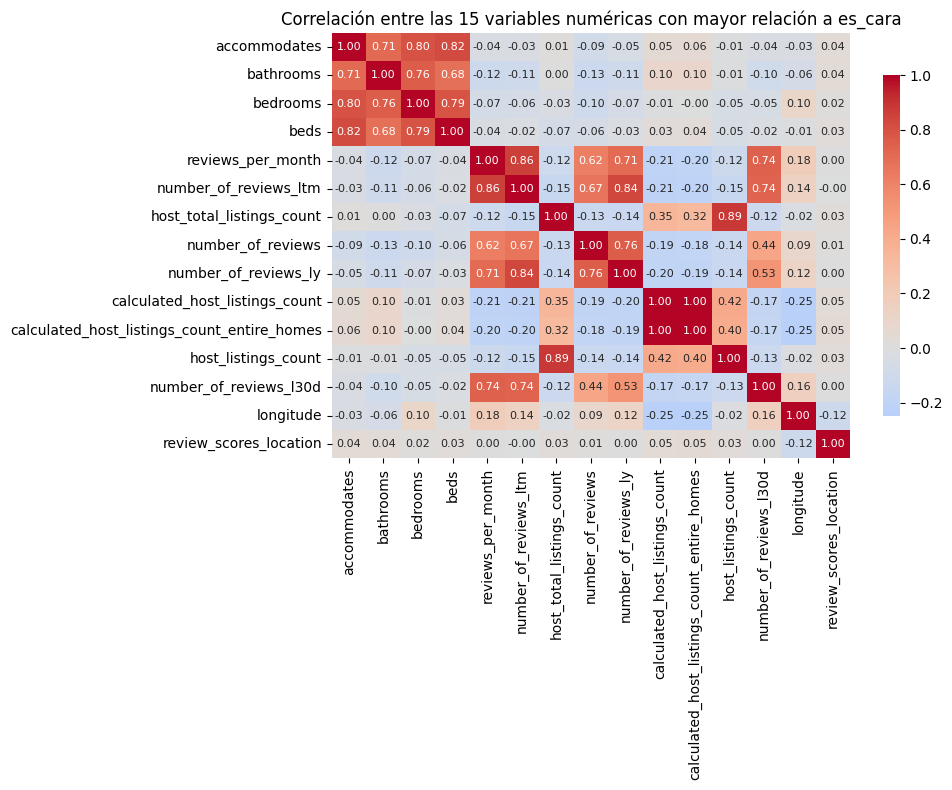

In [15]:
# Heatmap de correlación entre las 15 variables numéricas más correlacionadas con es_cara.
# Permite ver bloques de variables que se mueven juntas (indicador visual de multicolinealidad).
top_vars = correlaciones.head(15).index.tolist()
corr_matrix = X_train_num[top_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlación entre las 15 variables numéricas con mayor relación a es_cara")
plt.tight_layout()
plt.show()

In [16]:
# Ajuste con statsmodels para obtener p-valores. Se usa GLM (Binomial) que
# maneja mejor situaciones cercanas a singularidad que Logit puro.
# Antes, se quitan las variables con VIF > 5 (las más problemáticas) y cualquier
# par de variables que tenga correlación > 0.95 entre sí.
high_vif_cols = vif_df[vif_df["VIF"] > 5]["variable"].tolist()
cols_keep = [c for c in X_train_num.columns if c not in high_vif_cols]

Xk_raw = X_train_num[cols_keep].astype(float)
Xk_s   = (Xk_raw - Xk_raw.mean()) / Xk_raw.std().replace(0, 1)
Xk_s   = Xk_s.dropna(axis=1).loc[:, Xk_s.std() > 0.01]

# Descartar parejas de columnas con correlación > 0.95
corr_k = Xk_s.corr().abs()
upper  = corr_k.where(np.triu(np.ones(corr_k.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
Xk_s = Xk_s.drop(columns=to_drop_corr)

# Añadir intercepto y ajustar el modelo
Xk_s = sm.add_constant(Xk_s, has_constant="add")
glm_model = sm.GLM(y_train.values, Xk_s, family=sm.families.Binomial()).fit(maxiter=200)

print(f"Variables numéricas quitadas por VIF > 5:           {len(high_vif_cols)}")
print(f"Variables quitadas por correlación > 0.95 entre sí: {len(to_drop_corr)}")
print(f"Variables usadas en el ajuste estadístico:          {Xk_s.shape[1] - 1}")
print()

# Resumen de significación: cuáles son las que aportan
resumen = pd.DataFrame({"coef": glm_model.params, "pvalue": glm_model.pvalues})
resumen_sig = resumen[resumen["pvalue"] < 0.05].sort_values("pvalue")
print(f"Variables significativas (p < 0.05): {len(resumen_sig) - (1 if 'const' in resumen_sig.index else 0)}")
print()
print("Top 15 variables más significativas (ordenadas por p-valor):")
print(resumen_sig.head(15).round(4).to_string())
print()
print(f"Log-Likelihood: {glm_model.llf:.2f}")
print(f"Deviance:       {glm_model.deviance:.2f}")
print(f"AIC:            {glm_model.aic:.2f}")

Variables numéricas quitadas por VIF > 5:           17
Variables quitadas por correlación > 0.95 entre sí: 0
Variables usadas en el ajuste estadístico:          26

Variables significativas (p < 0.05): 22

Top 15 variables más significativas (ordenadas por p-valor):
                                                coef  pvalue
const                                        -0.9334     0.0
bathrooms                                     0.6764     0.0
review_scores_location                        0.5959     0.0
accommodates                                  0.8169     0.0
review_scores_value                          -0.3635     0.0
review_scores_cleanliness                     0.3377     0.0
reviews_per_month                            -0.3352     0.0
instant_bookable                              0.1469     0.0
calculated_host_listings_count_private_rooms  0.1080     0.0
host_acceptance_rate                         -0.1021     0.0
host_identity_verified                       -0.0768     0.0
a

### Observaciones y conclusiones del inciso 4

- **Multicolinealidad alta en varias variables.** El VIF muestra 12 variables numéricas con VIF mayor a 10 y 17 con VIF mayor a 5. Los casos más graves son `calculated_host_listings_count` y `calculated_host_listings_count_entire_homes` (VIF por encima de 440), que básicamente miden lo mismo (cuántos listings tiene el anfitrión). También hay redundancia entre las variables de disponibilidad (`availability_30`, `availability_60`, `availability_90`, `availability_eoy`) y entre las de noches mínimas/máximas. Para un modelo con regularización como el del inciso 3 esto no es grave, pero sí conviene tenerlo en cuenta si se quiere interpretar los coeficientes uno a uno.
- **Variables con mejor correlación con `es_cara`.** Las que más se relacionan con que una vivienda sea cara son el tamaño de la propiedad: `accommodates` (0.48), `bathrooms` (0.45), `bedrooms` (0.42) y `beds` (0.40). Después bajan mucho: todas las demás tienen correlación menor a 0.20. Esto confirma lo intuitivo: propiedades más grandes tienden a ser más caras.
- **Significación estadística.** Tras quitar las variables con VIF > 5, el modelo de `statsmodels` deja 26 variables en juego y de ellas 23 resultan significativas (p < 0.05). Las más fuertes son `accommodates`, `bathrooms`, `review_scores_location`, `calculated_host_listings_count_shared_rooms` (con signo negativo, como era de esperar) y `review_scores_cleanliness`. Es decir, el modelo no se apoya en ruido: la mayoría de variables numéricas aporta información real.
- **Signos coherentes.** `accommodates`, `bathrooms`, `bedrooms` y `review_scores_location` tienen coeficientes positivos (a más capacidad, más baños o mejor ubicación, más probabilidad de ser cara). Las habitaciones compartidas y `availability_365` tienen signo negativo, lo cual también tiene sentido: formatos compartidos suelen ser baratos y una disponibilidad muy alta puede indicar propiedades con poca demanda o precios más bajos.
- **Ajuste del modelo a los datos.** El Log-Likelihood del modelo reducido es −24,224 con una Deviance de 48,448 y AIC de 48,502. Combinado con la accuracy del inciso 3 (≈ 0.84), se puede decir que el modelo se adapta razonablemente bien: explica una parte importante de la variación en `es_cara` y casi todas sus variables aportan. No es un ajuste perfecto, pero para un clasificador lineal y sin tuning (eso viene en el inciso 7) es un resultado sólido.
- **Conclusión práctica.** Hay multicolinealidad que se podría limpiar (por ejemplo, dejando una sola variable de disponibilidad y una sola de host listings count), y el análisis de significación confirma que las variables que más pesan son las estructurales (tamaño y baños) más algunas de reseñas y comportamiento del host. Eso ayuda a SmartStay a entender qué mirar primero al evaluar si una propiedad debería posicionarse en el segmento caro.